In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (7043, 21)

First look:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Fix TotalCharges (stored as string in your file)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop 11 rows where TotalCharges is blank
df.dropna(inplace=True)

# Drop customerID — useless for analysis
df.drop('customerID', axis=1, inplace=True)

# Convert Churn to 0/1 for calculations
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaned shape:", df.shape)        # Should be (7032, 20)
print("Nulls remaining:", df.isnull().sum().sum())  # Should be 0
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")  # ~26.5%

Cleaned shape: (7032, 20)
Nulls remaining: 0

Churn rate: 26.6%


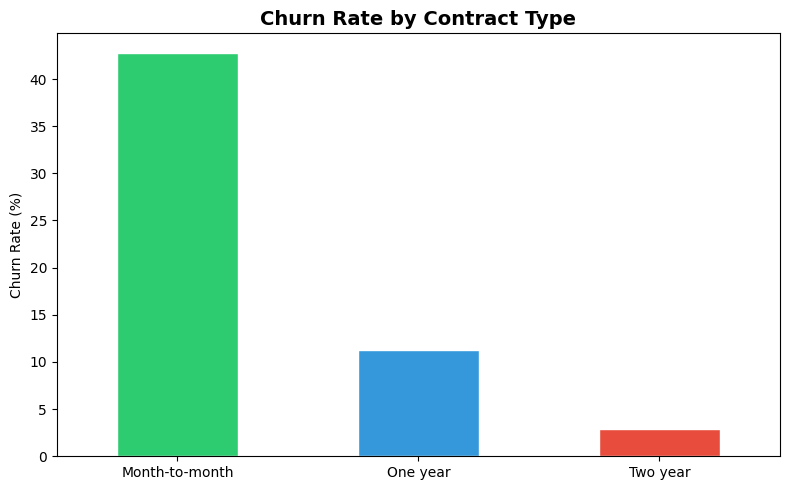

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()
print(contract_churn.round(1))

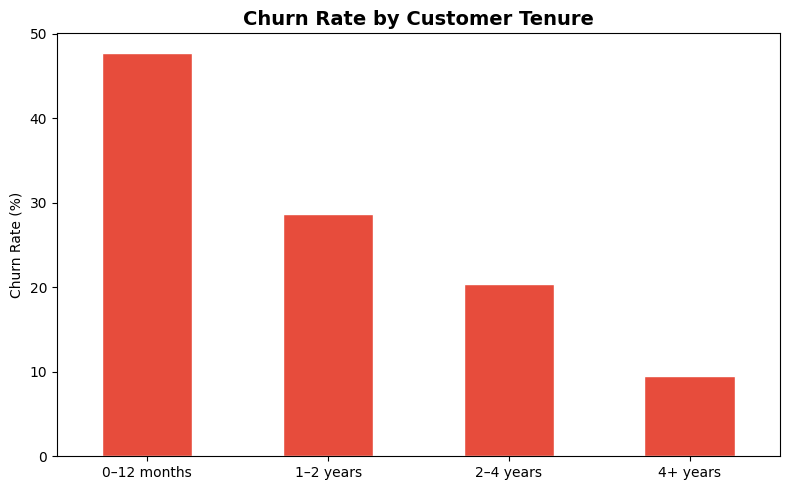

tenure_group
0–12 months    47.7
1–2 years      28.7
2–4 years      20.4
4+ years        9.5
Name: Churn, dtype: float64


In [ ]:
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 months', '1–2 years', '2–4 years', '4+ years'])

plt.figure(figsize=(8,5))
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()
print(tenure_churn.round(1))

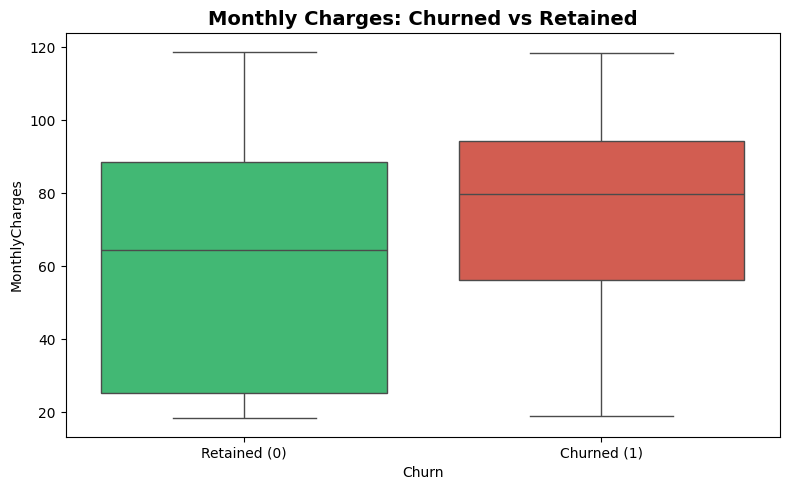

Avg charges - Retained: $61.31 | Churned: $74.44


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'0':'#2ecc71', '1':'#e74c3c'})  # ← strings here
plt.title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Retained (0)', 'Churned (1)'])
plt.tight_layout()
plt.savefig('charges_vs_churn.png', dpi=150)
plt.show()

avg = df.groupby('Churn')['MonthlyCharges'].mean()
print(f"Avg charges - Retained: ${avg[0]:.2f} | Churned: ${avg[1]:.2f}")

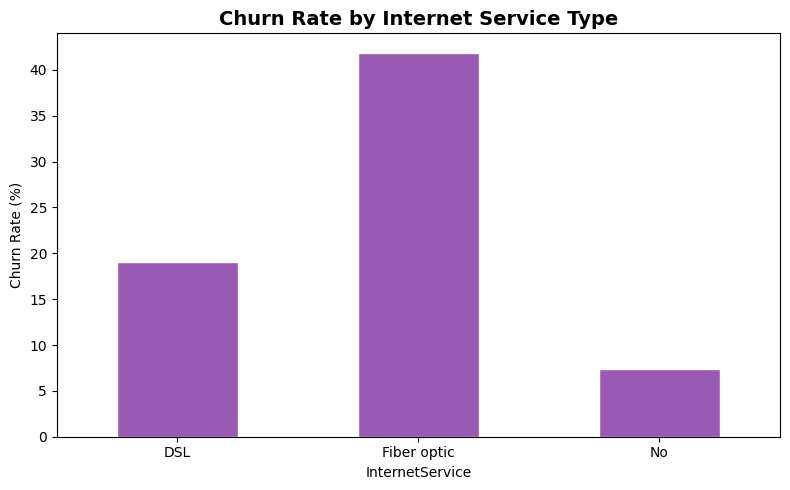

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
internet_churn.plot(kind='bar', color='#9b59b6', edgecolor='white')
plt.title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_internet.png', dpi=150)
plt.show()
print(internet_churn.round(1))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Encode text columns to numbers
df_model = df.drop('tenure_group', axis=1).copy()
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



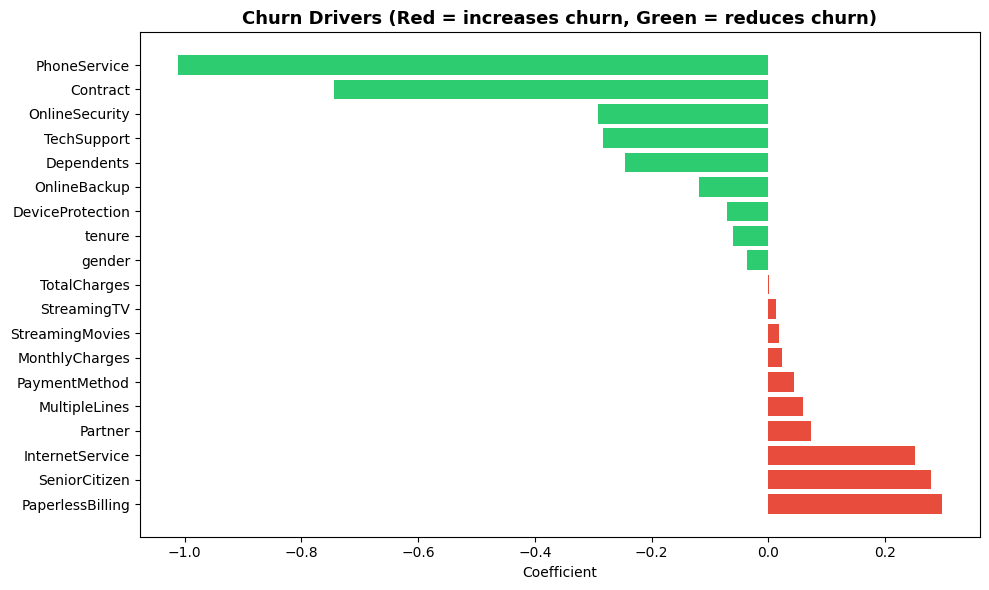

In [ ]:
import numpy as np

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.title('Churn Drivers (Red = increases churn, Green = reduces churn)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150)
plt.show()

In [ ]:
from google.colab import files

# Save and download cleaned CSV
df_export = df.copy()
df_export['Churn'] = df_export['Churn'].map({1: 'Yes', 0: 'No'})
df_export.to_csv('churn_cleaned.csv', index=False)

# Download all files
files.download('churn_cleaned.csv')
files.download('churn_by_contract.png')
files.download('churn_by_tenure.png')
files.download('charges_vs_churn.png')
files.download('churn_by_internet.png')
files.download('churn_drivers.png')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
